# Figures

Figures 1 to 5 of the paper, drawn from the result files in `results/`, followed by a section
for plotting any other run, including those produced by the method notebooks. Nothing is
trained here: this notebook needs no GPU and runs in a few seconds.

Every plotting choice is in this notebook, so edit it freely. By default the figures are only
displayed; set `SAVE_DIR` in the first cell to also write them as PNG files.

`make_figures.py` at the repository root draws the same figures as separate files, along with
the supporting figures that are not in the paper.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# The repository root is the folder holding run_experiment.py, wherever Jupyter was started.
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_experiment.py").exists())
RESULTS = REPO_ROOT / "results"

SAVE_DIR = None   # e.g. REPO_ROOT / "figures" / "mine" to also save every figure below as a PNG

# The style of the paper's figures: serif fonts, one 3.4 x 3.1 inch panel per plot.
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "dejavuserif", "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "figure.dpi": 110,
})
PANEL = (3.4, 3.1)


def show(fig, name):
    """Display a figure, and save it too when SAVE_DIR is set."""
    fig.tight_layout(pad=0.5)
    if SAVE_DIR is not None:
        Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
        fig.savefig(Path(SAVE_DIR) / f"{name}.png", dpi=300)
    plt.show()

## Reading the result files

Each training run writes one JSON file,
`results/<dataset>-labeled-<n>-seed-<seed>/<name>_metrics.json`, holding one list per metric
with one entry per evaluation (see `results/README.md`). `<name>` is the method, then `_ema`,
then the variant, if any.

The FLOPs axis is the number of iterations times the cost of one iteration, measured once per
method by `scripts/flops_analysis.py` (see `docs/flops.md`).

In [2]:
CONFIGS = {
    "svhn-250":      dict(dataset="svhn",     num_labeled=250,  target=0.90, widen_factor=2, title="SVHN"),
    "cifar10-250":   dict(dataset="cifar10",  num_labeled=250,  target=0.80, widen_factor=2, title="CIFAR-10"),
    "cifar10-4000":  dict(dataset="cifar10",  num_labeled=4000, target=0.90, widen_factor=2, title="CIFAR-10"),
    "cifar100-2500": dict(dataset="cifar100", num_labeled=2500, target=0.50, widen_factor=4, title="CIFAR-100"),
}
METHODS = ["efficientmatch", "fixmatch", "flexmatch", "mixmatch", "regmixmatch"]
BUDGET_MIN = 120   # evaluations after the two-hour budget are never plotted

# GFLOPs per training iteration, per WideResNet width (docs/flops.md).
GFLOPS_PER_IT = {
    2: {"efficientmatch": 740.35, "fixmatch": 850.10, "flexmatch": 850.10, "mixmatch": 301.64,
        "regmixmatch": 1891.86, "efficientmatch_mu1": 356.46, "efficientmatch_mu5": 1124.25,
        "efficientmatch_mu7": 1508.14, "regmixmatch_mu3": 904.80},
    4: {"efficientmatch": 2921.93, "fixmatch": 3354.88, "flexmatch": 3354.88, "mixmatch": 1190.43,
        "regmixmatch": 7467.01},
}


def result_dir(config, seed):
    c = CONFIGS[config]
    return RESULTS / f"{c['dataset']}-labeled-{c['num_labeled']}-seed-{seed}"


def load(config, seed, name):
    """The metrics of one run, e.g. load("cifar10-250", 2312, "efficientmatch_ema")."""
    return json.loads((result_dir(config, seed) / f"{name}_metrics.json").read_text())


def default_name(method, config):
    """The name of the paper's run of a method: <method>_ema, with _wf4 on CIFAR-100."""
    return f"{method}_ema" + ("_wf4" if CONFIGS[config]["widen_factor"] == 4 else "")


def gflops_per_it(name, widen_factor):
    """Cost of one iteration of the run called `name`: the longest known prefix of its name."""
    parts = name.replace("_ema", "").split("_")
    for i in range(len(parts), 0, -1):
        key = "_".join(parts[:i])
        if key in GFLOPS_PER_IT[widen_factor]:
            return GFLOPS_PER_IT[widen_factor][key]
    raise KeyError(f"no FLOPs per iteration known for {name!r}: add it to GFLOPS_PER_IT")


def within_budget(run, budget=True):
    """The run's evaluations, cut at the two-hour budget unless budget=False."""
    keep = [i for i, t in enumerate(run["time_elapsed"]) if not budget or t / 60 <= BUDGET_MIN]
    return {key: [values[i] for i in keep] for key, values in run.items() if len(values) == len(run["step"])}

## One comparison panel

`comparison_panel` draws accuracy against time, iterations or FLOPs for several runs of one
configuration and seed. It is what Figures 2, 4 and 5 are made of.

`FRAMING` holds each configuration's axis limits, as in the paper. The y-axis starts where the
methods separate, since showing 0 to 1 would bunch every curve against the top. `"auto"` for
the x-axis zooms in on the methods that reach the target, so that a method that never does
simply runs off the right edge. `"auto"` for the y-axis leaves the top quarter of the panel
free for a two-column legend. A fixed x limit is given per axis, since each has its own unit.

In [3]:
FRAMING = {
    "svhn-250":      dict(ymin=0.75, ymax="auto", xmax={"time": 45, "steps": 43_500, "flops": 3.7e7},
                          auto_xmin=True, legend="top"),
    "cifar10-250":   dict(ymin=0.60, ymax=0.85,   xmax="auto", auto_xmin=False, legend="best"),
    "cifar10-4000":  dict(ymin=0.85, ymax="auto", xmax="auto", auto_xmin=True,  legend="top"),
    "cifar100-2500": dict(ymin=0.30, ymax="auto", xmax="auto", auto_xmin=True,  legend="top"),
}
AXIS_LABEL = {"time": "Time (min)", "steps": "Iterations", "flops": "Cumulated GFLOPs"}


def comparison_panel(ax, config, seed, xaxis, runs=None, budget=True, show_target=True, framing=None):
    """Accuracy against `xaxis` ("time", "steps" or "flops") on one configuration and seed.

    runs: {legend label: result name}, the five methods of the paper by default.
    framing: overrides for FRAMING[config], e.g. dict(xmax=30) or dict(ymin=0.5, ymax=0.9).
    """
    c = CONFIGS[config]
    f = dict(FRAMING[config], **(framing or {}))
    runs = runs or {m: default_name(m, config) for m in METHODS}

    curves = []
    for label, name in runs.items():
        run = within_budget(load(config, seed, name), budget)
        if xaxis == "time":
            x = [t / 60 for t in run["time_elapsed"]]
        elif xaxis == "steps":
            x = run["step"]
        else:
            x = [s * gflops_per_it(name, c["widen_factor"]) for s in run["step"]]
        curves.append((x, run["test_acc"]))
        ax.plot(x, run["test_acc"], label=label, linewidth=1.3)

    # x-axis: zoom on the methods that reach the target, leaving out extreme outliers.
    xmax = f["xmax"][xaxis] if isinstance(f["xmax"], dict) else f["xmax"]   # a fixed limit, per axis
    if xmax == "auto":
        xmax = max(x[-1] for x, _ in curves)
        ends = sorted(x[-1] for x, acc in curves if max(acc) >= c["target"] - 1e-9)
        if len(ends) >= 2:
            median = (ends[(len(ends) - 1) // 2] + ends[len(ends) // 2]) / 2
            xmax = 1.04 * max(e for e in ends if e <= 2.5 * median)
        if xaxis == "time":
            xmax = min(xmax, BUDGET_MIN)
    xmin = 0.0
    if f["auto_xmin"]:   # drop the empty margin left of where the first curve enters the panel
        firsts = [next(xi for xi, a in zip(x, acc) if a >= f["ymin"]) for x, acc in curves if max(acc) >= f["ymin"]]
        if firsts and min(firsts) > 0.06 * xmax:
            xmin = 0.9 * min(firsts)
    ymax = f["ymax"]
    if ymax == "auto":   # keep the top ~25% of the panel free for the legend
        top = max([c["target"]] + [a for x, acc in curves for xi, a in zip(x, acc) if xmin <= xi <= xmax])
        ymax = math.ceil((f["ymin"] + (top + 0.005 - f["ymin"]) / 0.74) / 0.005) * 0.005

    if show_target:
        ax.axhline(c["target"], color="black", linestyle="--", linewidth=1.0, alpha=0.7,
                   label=f"target {c['target'] * 100:.0f}%")
    ax.set_xlabel(AXIS_LABEL[xaxis])
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{c['title']}, {c['num_labeled']} labels\nseed {seed}", fontweight="bold", fontsize=11, pad=4)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(f["ymin"], ymax)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    if xaxis == "steps":
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k" if v >= 1000 else f"{v:g}"))
    ax.grid(True, alpha=0.3, linewidth=0.5)
    if f["legend"] == "top":
        ax.legend(loc="upper center", ncol=2, frameon=True, framealpha=0.9, fontsize=7, columnspacing=1.0,
                  handlelength=1.6, borderpad=0.3, labelspacing=0.25)
    else:
        ax.legend(loc=f["legend"], frameon=True, framealpha=0.85, fontsize=8)


def accuracy_vs_pl_panel(ax, run, title, budget=True):
    """Model accuracy and pseudo-label quality over time, in percent (Figures 1 and 3)."""
    run = within_budget(run, budget)
    t = [s / 60 for s in run["time_elapsed"]]
    ax.plot(t, [100 * v for v in run["test_acc"]], label="Model accuracy", lw=1.5)
    ax.plot(t, [100 * v for v in run["pl_quality"]], label="Pseudo-label quality", lw=1.5)
    ax.set_ylim(50, 84)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3, lw=0.5)
    ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.85)

## Figure 1 — pseudo-label quality versus model accuracy

*Evolution over training of pseudo-label quality (used in the loss) versus model accuracy, for
FixMatch (left), MixMatch (middle) and EfficientMatch (right), on a CIFAR-10, 250-label
configuration. Model accuracy closely tracks the accuracy of the retained pseudo-labels for
FixMatch, whereas the model surpasses pseudo-label quality for MixMatch. We can see that
EfficientMatch inherits both the pseudo-label quality and the improvement from the Mixup.*

Seed 2701.

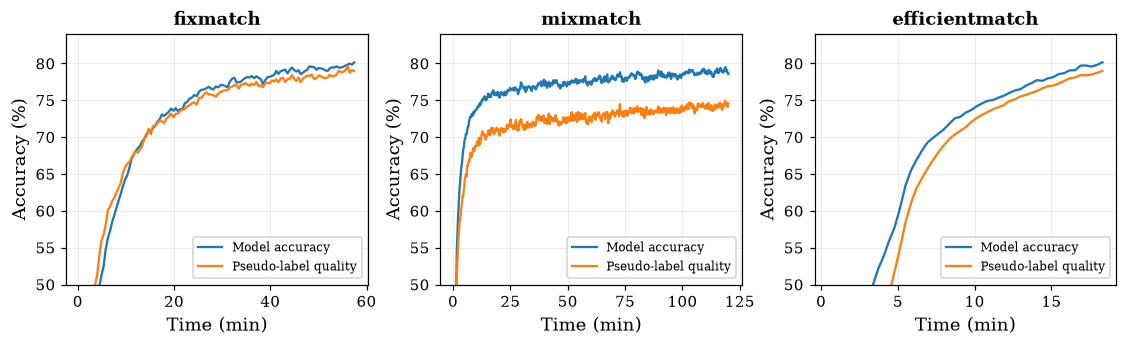

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL[0], PANEL[1]))
for ax, method in zip(axes, ["fixmatch", "mixmatch", "efficientmatch"]):
    accuracy_vs_pl_panel(ax, load("cifar10-250", 2701, f"{method}_ema"), method)
show(fig, "figure1")

## Figure 2 — three criteria, three rankings

*Convergence of EfficientMatch compared to MixMatch, FixMatch, and FlexMatch on CIFAR-10/250,
seed 2701, along the three criteria: iterations (left), time (middle), and FLOPs (right). The
three criteria rank methods differently. RegMixMatch appears highly efficient per iteration,
whereas EfficientMatch is more efficient on the other two criteria, except early in training,
where MixMatch dominates before reaching its plateau.*

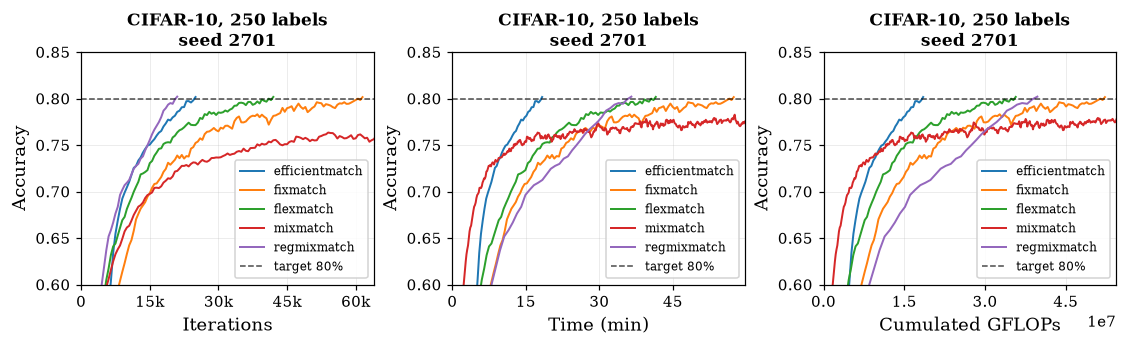

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL[0], PANEL[1]))
for ax, xaxis in zip(axes, ["steps", "time", "flops"]):
    comparison_panel(ax, "cifar10-250", 2701, xaxis)
show(fig, "figure2")

## Figure 3 — the weight of the Mixup loss

*Evolution over training of accuracy (right) for the three Mixup weights (0.5, 1, 2),
pseudo-label quality (used in the loss) versus model accuracy for $\lambda_{mix} = 0.5$ and
$\lambda_{mix} = 2$ on CIFAR-10 250 labels seed 2312 configuration.*

The runs are EfficientMatch with `--mixup_weight 0.5`, the default 1, and `--mixup_weight 2.0`.
As in the paper, these panels are not cut at the two-hour budget.

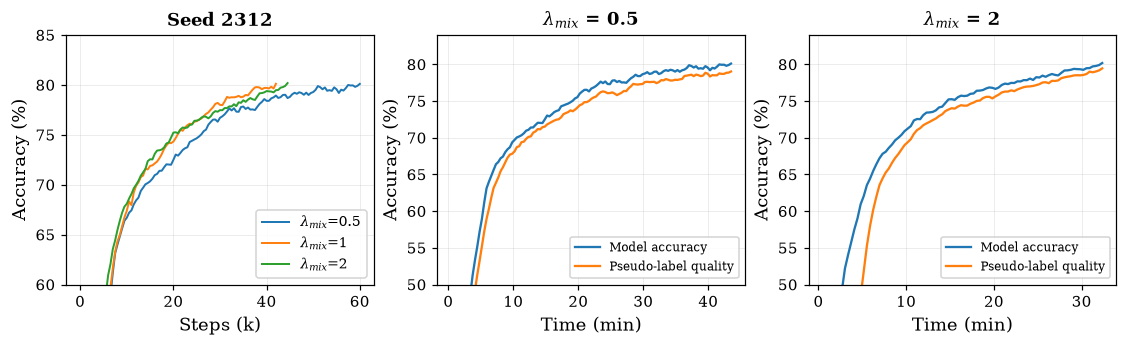

In [6]:
MIXUP_WEIGHTS = {"0.5": "efficientmatch_ema_mixw0.5", "1": "efficientmatch_ema", "2": "efficientmatch_ema_mixw2.0"}
runs = {w: load("cifar10-250", 2312, name) for w, name in MIXUP_WEIGHTS.items()}

fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL[0], PANEL[1]))
for w, run in runs.items():
    axes[0].plot([s / 1000 for s in run["step"]], [100 * a for a in run["test_acc"]],
                 label=rf"$\lambda_{{mix}}$={w}", lw=1.3)
axes[0].set_ylim(60, 85)
axes[0].set_xlabel("Steps (k)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Seed 2312", fontweight="bold")
axes[0].grid(alpha=0.3, lw=0.5)
axes[0].legend(loc="lower right", frameon=True, framealpha=0.85, fontsize=9)
for ax, w in zip(axes[1:], ["0.5", "2"]):
    accuracy_vs_pl_panel(ax, runs[w], rf"$\lambda_{{mix}}$ = {w}", budget=False)
show(fig, "figure3")

## Figure 4 — the four configurations

*Accuracy vs. time, all five reference methods, seed 2312, one panel per configuration. Dashed
lines mark $\tau_{acc}$.*

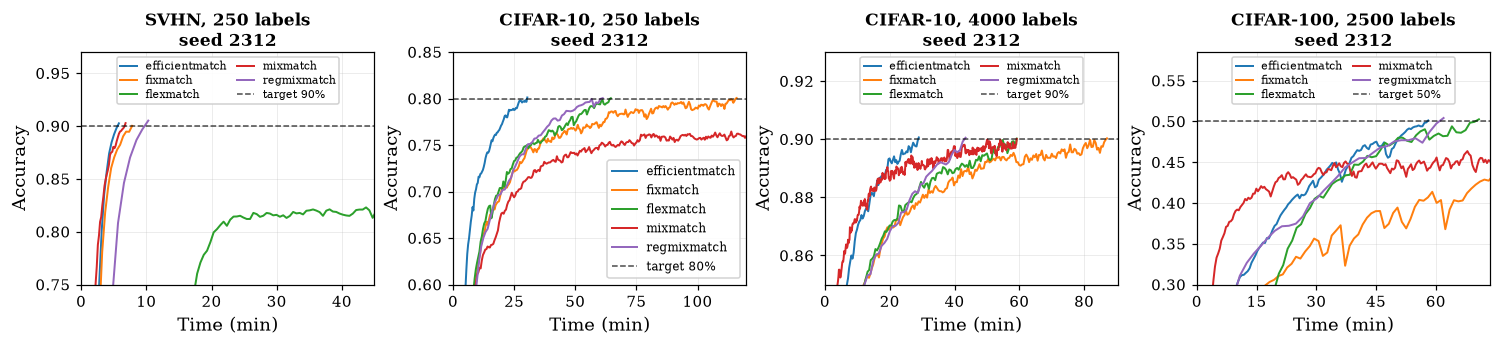

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(4 * PANEL[0], PANEL[1]))
for ax, config in zip(axes, CONFIGS):
    comparison_panel(ax, config, 2312, "time")
show(fig, "figure4")

## Figure 5 — the three seeds

*Accuracy vs. time, all methods, CIFAR-10/250, one panel per seed. Panel (a) is identical to
Figure 4(b), shown again here for direct seed-to-seed comparison.*

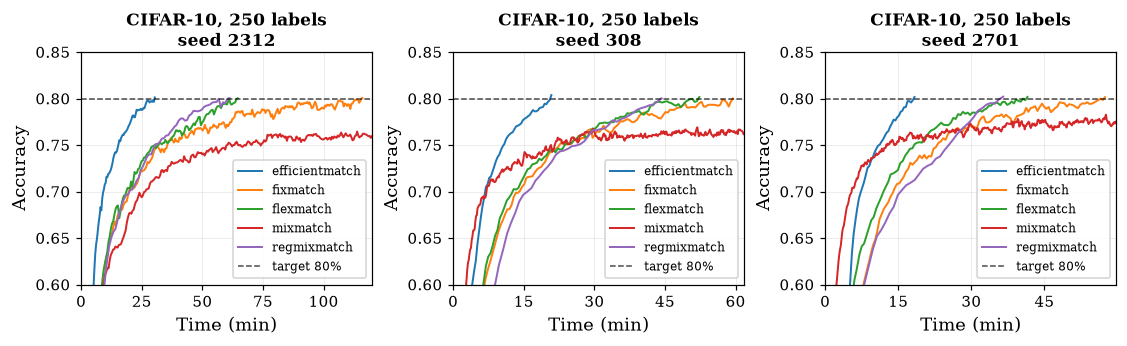

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL[0], PANEL[1]))
for ax, seed in zip(axes, [2312, 308, 2701]):
    comparison_panel(ax, "cifar10-250", seed, "time")
show(fig, "figure5")

## Your own runs

Every result file of one configuration and seed, the paper's and any produced since. A run
from a method notebook is named `<method>_ema_notebook` (`_wf4` before `_notebook` on
CIFAR-100).

In [9]:
CONFIG, SEED = "cifar10-250", 2312
print(sorted(p.name.removesuffix("_metrics.json") for p in result_dir(CONFIG, SEED).glob("*_metrics.json")))

['efficientmatch_ema', 'efficientmatch_ema_mixw0.5', 'efficientmatch_ema_mixw2.0', 'efficientmatch_ema_mu1', 'efficientmatch_ema_mu5', 'efficientmatch_ema_mu7', 'efficientmatch_freematch_ema', 'efficientmatch_hard_ema', 'efficientmatch_soft_ema', 'fast_fixmatch_ema', 'fixmatch_ema', 'fixmatch_ema_orig', 'fixmatch_mu3_ema', 'flexmatch_ema', 'mixmatch_ema', 'regmixmatch_ema', 'regmixmatch_mu3_ema']


Pass any of these names to `comparison_panel` as `{legend label: result name}`. The example
below compares the EfficientMatch run of the paper with its $\lambda_{mix} = 2$ variant, in
iterations; replace one with `"efficientmatch_ema_notebook"` to add your own run.
`budget=False` keeps a run's evaluations past the two-hour budget, and
`framing=dict(ymin=..., ymax=..., xmax=...)` changes the axis limits.

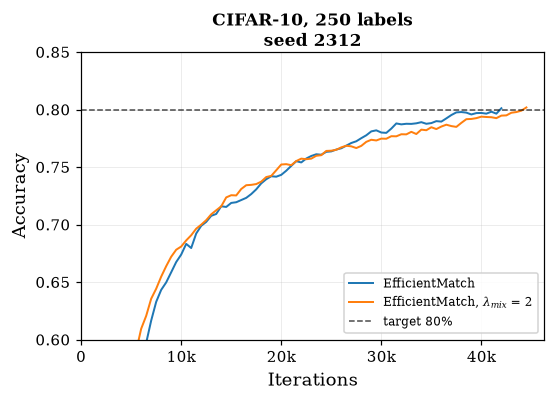

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.6))
comparison_panel(ax, CONFIG, SEED, "steps", runs={
    "EfficientMatch": "efficientmatch_ema",
    r"EfficientMatch, $\lambda_{mix}$ = 2": "efficientmatch_ema_mixw2.0",
})
show(fig, "my_comparison")